**Step 1: Install required libraries**

In [3]:
!pip install gdown matplotlib opencv-python scikit-image seaborn --quiet

**Step 2: Import libraries**

In [4]:
import gdown
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import color

**Step 3: Download images from Google Drive using gdown**

In [5]:
source_url = "https://drive.google.com/uc?id=1U6RCvnYtLPUgfOhRy3c60aEeC_E07Y8I"
target_url = "https://drive.google.com/uc?id=1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R"

gdown.download(source_url, "source.jpg", quiet=False)
gdown.download(target_url, "target.jpg", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1U6RCvnYtLPUgfOhRy3c60aEeC_E07Y8I
To: /content/source.jpg
100%|██████████| 133k/133k [00:00<00:00, 47.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R
To: /content/target.jpg
100%|██████████| 92.6k/92.6k [00:00<00:00, 13.6MB/s]


'target.jpg'

**Step 4: Load images in RGB**


In [6]:
# OpenCV loads images in BGR by default, so we convert to RGB
source = cv2.cvtColor(cv2.imread("source.jpg"), cv2.COLOR_BGR2RGB)
target = cv2.cvtColor(cv2.imread("target.jpg"), cv2.COLOR_BGR2RGB)

**Step 5: Define a function for RGB to LAB color space conversion**

    LAB separates luminance (L) and chromaticity (A, B)

In [7]:
def rgb_to_lab(img):
    """
    Convert an RGB image to LAB color space
    Formula: OpenCV cvtColor uses standard CIE-LAB conversion
    """
    return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

**Step 6: Define a function for LAB to RGB conversion**

In [8]:
def lab_to_rgb(img_lab):
    """
    Convert a LAB image back to RGB color space
    """
    return cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

**Step 7: Convert both images to LAB**

In [9]:
source_lab = rgb_to_lab(source)
target_lab = rgb_to_lab(target)

**Step 8: Compute mean and standard deviation of L, A, B channels**

In [10]:
def get_mean_std(img_lab):
    """
    Compute mean and standard deviation for each channel in LAB image
    """
    l, a, b = cv2.split(img_lab)
    l_mean, l_std = cv2.meanStdDev(l)
    a_mean, a_std = cv2.meanStdDev(a)
    b_mean, b_std = cv2.meanStdDev(b)

    # Flatten arrays to get scalar values
    return l_mean[0][0], a_mean[0][0], b_mean[0][0], l_std[0][0], a_std[0][0], b_std[0][0]

# Get statistics
source_l_mean, source_a_mean, source_b_mean, source_l_std, source_a_std, source_b_std = get_mean_std(source_lab)
target_l_mean, target_a_mean, target_b_mean, target_l_std, target_a_std, target_b_std = get_mean_std(target_lab)

**Step 9: Perform color transfer in LAB space**

In [11]:
def color_transfer(source_stats, target_lab):
    """
    Transfers the color statistics from the source to the target image.
    Formula:
    L_t' = ((L_t - mean_Lt) * (std_Ls / std_Lt)) + mean_Ls
    A_t' = ((A_t - mean_At) * (std_As / std_At)) + mean_As
    B_t' = ((B_t - mean_Bt) * (std_Bs / std_Bt)) + mean_Bs
    """
    l_mean_s, a_mean_s, b_mean_s, l_std_s, a_std_s, b_std_s = source_stats

    # Split target LAB channels
    l, a, b = cv2.split(target_lab)

    # Apply formula for each channel
    l = ((l - target_l_mean) * (l_std_s / target_l_std)) + l_mean_s
    a = ((a - target_a_mean) * (a_std_s / target_a_std)) + a_mean_s
    b = ((b - target_b_mean) * (b_std_s / target_b_std)) + b_mean_s

    # Merge channels and clip values to valid range [0,255]
    transfer = cv2.merge([l, a, b])
    transfer = np.clip(transfer, 0, 255).astype(np.uint8)
    return transfer

**Step 10: Apply color transfer**

In [12]:
result_lab = color_transfer(
    (source_l_mean, source_a_mean, source_b_mean, source_l_std, source_a_std, source_b_std),
    target_lab
)
result_rgb = lab_to_rgb(result_lab)

**Step 11: Visualization functions**

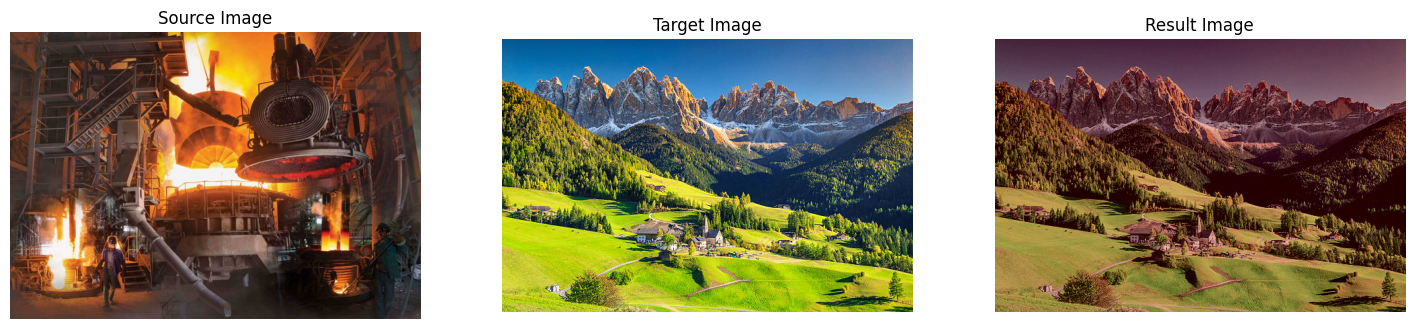

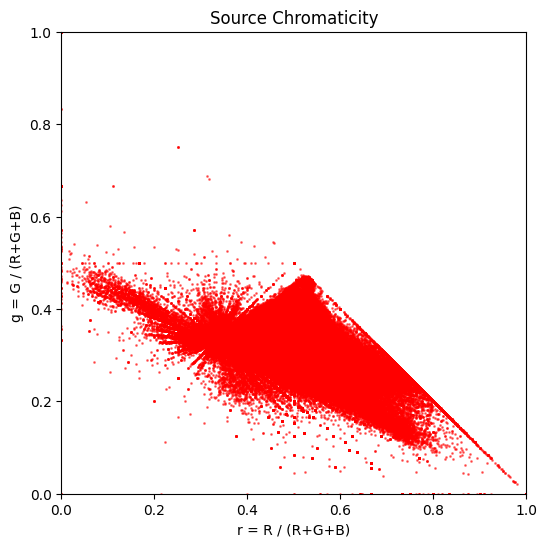

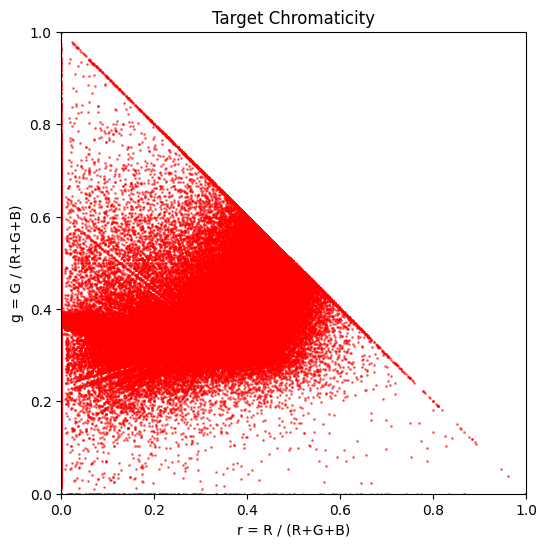

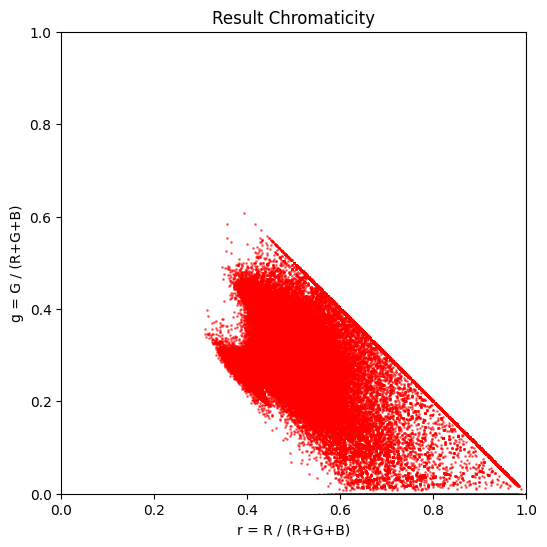

In [13]:
def plot_images(source, target, result):
    """
    Plot source, target, and resulting image side by side
    """
    plt.figure(figsize=(18,6))
    plt.subplot(1,3,1)
    plt.imshow(source)
    plt.title("Source Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(target)
    plt.title("Target Image")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(result)
    plt.title("Result Image")
    plt.axis('off')
    plt.show()

def plot_chromaticity(img, title="Chromaticity Diagram"):
    """
    Plot chromaticity (r, g) diagram where
    r = R / (R+G+B), g = G / (R+G+B)
    """
    R = img[:,:,0].astype(np.float32)
    G = img[:,:,1].astype(np.float32)
    B = img[:,:,2].astype(np.float32)
    sum_rgb = R + G + B + 1e-6
    r = R / sum_rgb
    g = G / sum_rgb

    plt.figure(figsize=(6,6))
    plt.scatter(r.flatten(), g.flatten(), color='red', s=1, alpha=0.5)
    plt.xlabel("r = R / (R+G+B)")
    plt.ylabel("g = G / (R+G+B)")
    plt.title(title)
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.show()

# Plot results
plot_images(source, target, result_rgb)
plot_chromaticity(source, "Source Chromaticity")
plot_chromaticity(target, "Target Chromaticity")
plot_chromaticity(result_rgb, "Result Chromaticity")

**Step 12: Optionally, show RGB histograms**

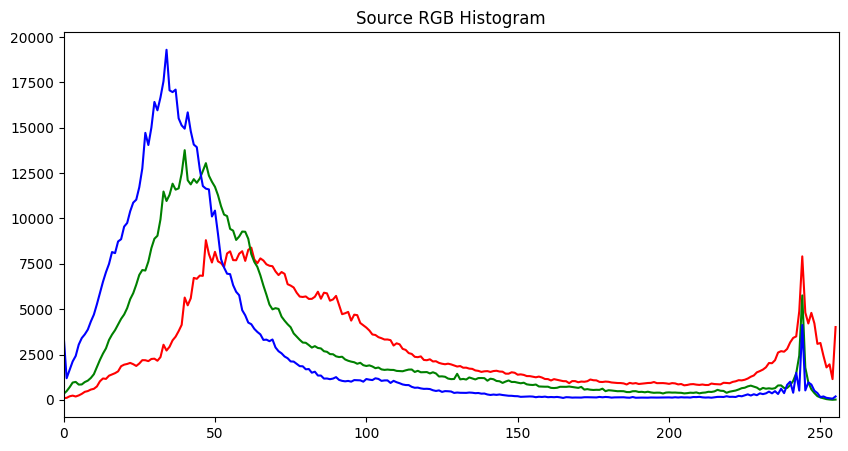

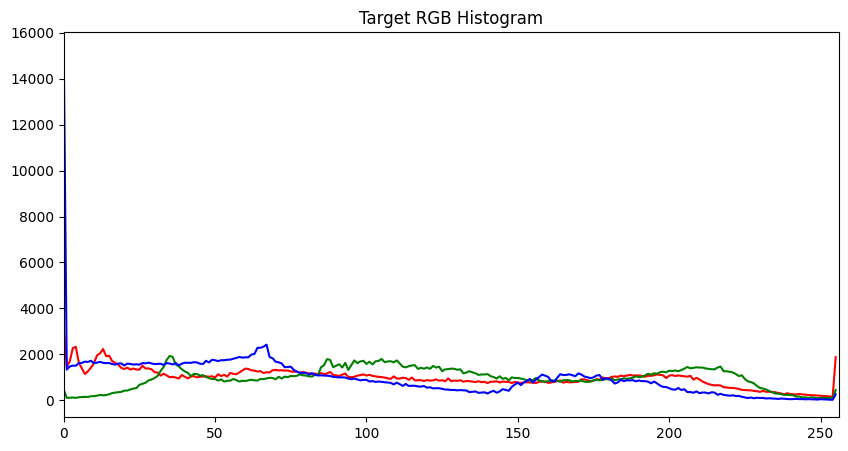

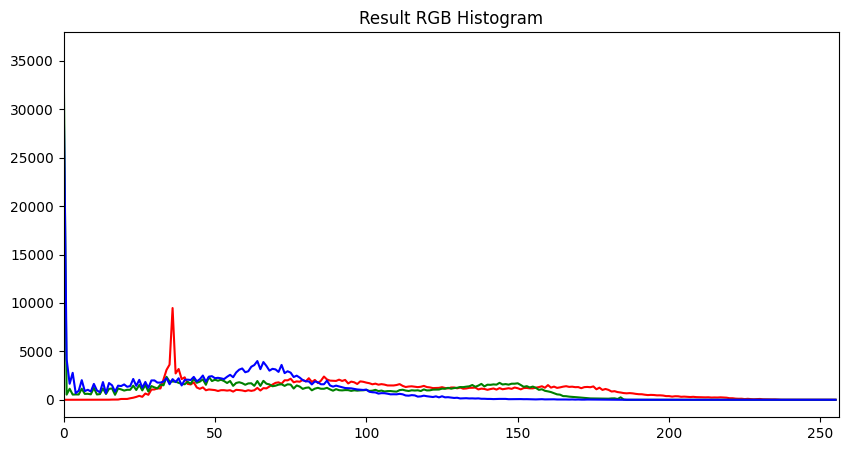

In [14]:
def plot_rgb_histogram(img, title="RGB Histogram"):
    """
    Plot RGB histogram for each channel
    """
    colors = ('r','g','b')
    plt.figure(figsize=(10,5))
    for i,col in enumerate(colors):
        hist = cv2.calcHist([img],[i],None,[256],[0,256])
        plt.plot(hist, color=col)
        plt.xlim([0,256])
    plt.title(title)
    plt.show()

plot_rgb_histogram(source, "Source RGB Histogram")
plot_rgb_histogram(target, "Target RGB Histogram")
plot_rgb_histogram(result_rgb, "Result RGB Histogram")

**Summary**

    This code transfers color from a source image to a target image and visualizes results.
    
    Includes chromaticity diagrams, RGB histograms, and fully commented steps for students.